In [1]:
import pandas as pd

df = pd.read_csv("../data/data_jobs.csv")

df.head()


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [2]:
df.shape

(2253, 16)

In [3]:
df = df.drop("Unnamed: 0", axis=1)

In [4]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='str')

In [5]:
df.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [6]:
df.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [7]:
df.describe()

,Rating,Founded
count,2253.000000,2253.000000
mean,3.160630,1398.522858
std,1.665228,901.929251
min,-1.000000,-1.000000
25%,3.100000,-1.000000
50%,3.600000,1979.000000
75%,4.000000,2002.000000
max,5.000000,2019.000000


In [8]:
df.dtypes

Job Title                str
Salary Estimate          str
Job Description          str
Rating               float64
Company Name             str
Location                 str
Headquarters             str
Size                     str
Founded                int64
Type of ownership        str
Industry                 str
Sector                   str
Revenue                  str
Competitors              str
Easy Apply               str
dtype: object

In [9]:
df['Industry'].value_counts().head()

Industry
-1                                  353
IT Services                         325
Staffing & Outsourcing              323
Health Care Services & Hospitals    151
Consulting                          111
Name: count, dtype: int64

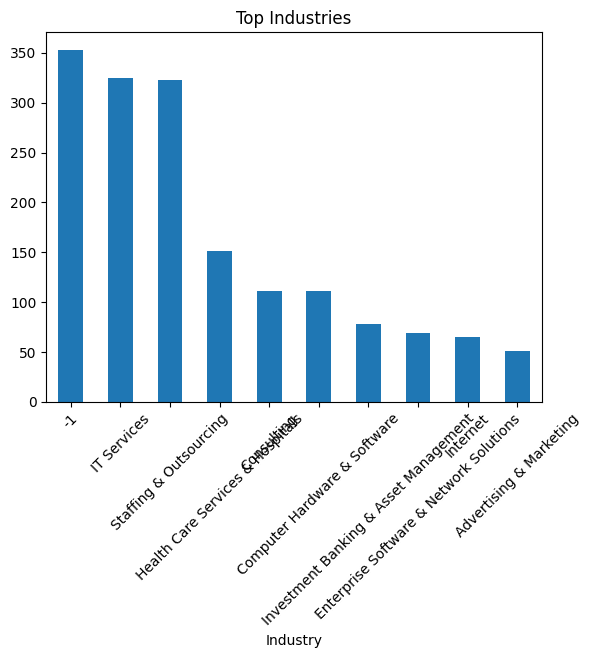

In [10]:
#Строим график
import matplotlib.pyplot as plt

df["Industry"].value_counts().head(10).plot(kind="bar")

plt.title("Top Industries")
plt.xticks(rotation=45)

plt.show()


Очистка данных

In [11]:
df['Salary Estimate'].head(10)

0    $37K-$66K (Glassdoor est.)
1    $37K-$66K (Glassdoor est.)
2    $37K-$66K (Glassdoor est.)
3    $37K-$66K (Glassdoor est.)
4    $37K-$66K (Glassdoor est.)
5    $37K-$66K (Glassdoor est.)
6    $37K-$66K (Glassdoor est.)
7    $37K-$66K (Glassdoor est.)
8    $37K-$66K (Glassdoor est.)
9    $37K-$66K (Glassdoor est.)
Name: Salary Estimate, dtype: str

In [12]:
df["Salary Estimate"] = df["Salary Estimate"].str.replace("(Glassdoor est.)", "", regex=False)

In [13]:
df["Salary Estimate"] = df["Salary Estimate"].str.replace("$", "", regex=False)

In [14]:
df["Salary Estimate"] = df["Salary Estimate"].str.replace("K", "", regex=False)

In [15]:
df["Salary Estimate"].head()

0    37-66 
1    37-66 
2    37-66 
3    37-66 
4    37-66 
Name: Salary Estimate, dtype: str

In [16]:
df[["min_salary", "max_salary"]] = df["Salary Estimate"].str.split("-", expand=True)

In [17]:
df["min_salary"] = pd.to_numeric(df["min_salary"], errors="coerce")
df["max_salary"] = pd.to_numeric(df["max_salary"], errors="coerce")

In [18]:
df["avg_salary"] = (df["min_salary"] + df["max_salary"]) / 2

In [19]:
df[["min_salary", "max_salary", "avg_salary"]].head()

,min_salary,max_salary,avg_salary
0,37.0,66,51.5
1,37.0,66,51.5
2,37.0,66,51.5
3,37.0,66,51.5
4,37.0,66,51.5


Анализ зарплат

In [20]:

df["avg_salary"].max()

np.float64(150.0)

In [21]:

df["avg_salary"].min()

np.float64(33.5)

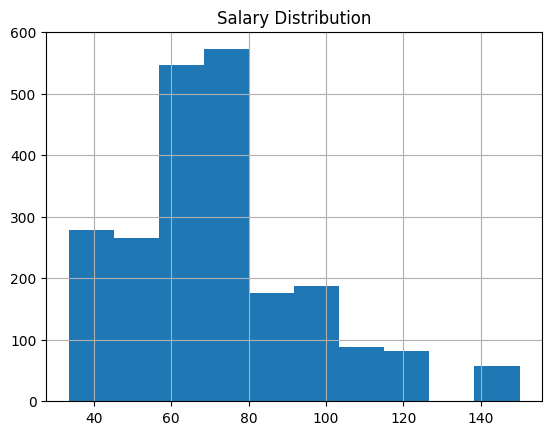

In [22]:

df["avg_salary"].hist()

plt.title("Salary Distribution")

plt.show()

In [23]:

df.groupby("Industry")["avg_salary"].mean().sort_values(ascending=False).head(10)

Industry
Drug & Health Stores                      95.250000
Education Training Services               92.833333
Health Care Products Manufacturing        89.800000
Sports & Recreation                       88.166667
Gambling                                  88.000000
News Outlet                               87.000000
Transportation Equipment Manufacturing    85.000000
Electrical & Electronic Manufacturing     84.666667
Utilities                                 83.250000
Biotech & Pharmaceuticals                 83.106061
Name: avg_salary, dtype: float64

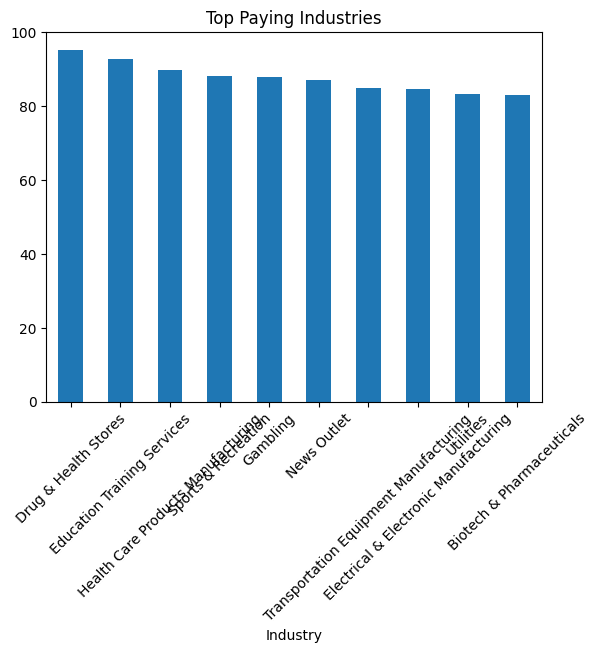

In [24]:
 
top_industries = (
    df.groupby("Industry")["avg_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_industries.plot(kind="bar")

plt.title("Top Paying Industries")

plt.xticks(rotation=45)

plt.show()

In [25]:

df.groupby("Company Name")["avg_salary"] \
.mean() \
.sort_values(ascending=False) \
.head(10)

Company Name
Zipongo\n4.0            150.0
OSI Engineering\n4.5    150.0
Nuro\n4.4               150.0
Enjoy\n3.8              150.0
Netflix\n3.9            150.0
Alteryx\n3.3            150.0
Xcutives.com Inc        150.0
Ursus\n4.4              150.0
Iconma, L.L.C.\n3.6     150.0
Tesla Motors\n3.4       150.0
Name: avg_salary, dtype: float64

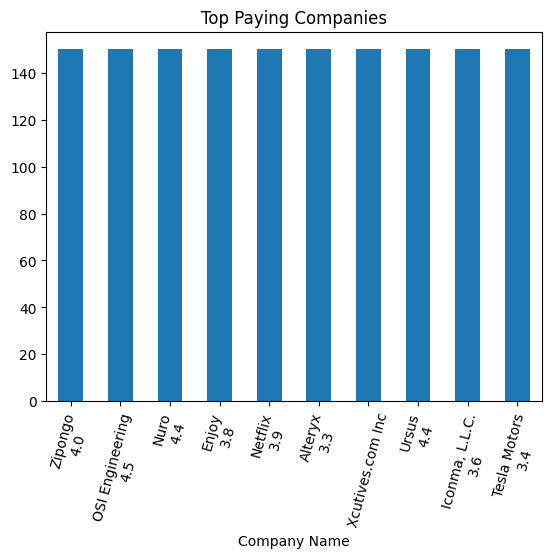

In [26]:
top_companies = (
    df.groupby("Company Name")["avg_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_companies.plot(kind="bar")

plt.title("Top Paying Companies")

plt.xticks(rotation=75)

plt.show()